In [1]:
from collections import defaultdict
import random
from random import choice
import torchvision
import torch
import torch.optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import numpy as np
import time
from matplotlib import pyplot as plt

In [2]:
class MNISTMetricDataset(Dataset):
    def __init__(self, root="/tmp/mnist/", split='train', remove_class=None):
        super().__init__()
        assert split in ['train', 'test', 'traineval']
        self.root = root
        self.split = split
        mnist_ds = torchvision.datasets.MNIST(self.root, train='train' in split, download=True)
        self.images, self.targets = mnist_ds.data.float() / 255., mnist_ds.targets
        self.classes = list(range(10))

        if remove_class is not None:
            self.classes.remove(remove_class)
            self.images = self.images[self.targets != remove_class]
            self.targets = self.targets[self.targets != remove_class]

        self.target2indices = defaultdict(list)
        for i in range(len(self.images)):
            self.target2indices[self.targets[i].item()] += [i]

    def _sample_negative(self, index):
        anchor_target = self.targets[index].item()
        negative_classes = []
        for c in self.classes:
            if c != anchor_target:
                negative_classes.append(c)
        negative_target = random.choice(negative_classes)
        negative_indices = self.target2indices[negative_target]
        return random.choice(negative_indices)


    def _sample_positive(self, index):
        anchor_target = self.targets[index].item()
        positive_indices = self.target2indices[anchor_target]
        return random.choice(positive_indices)


    def __getitem__(self, index):
        anchor = self.images[index].unsqueeze(0)
        target_id = self.targets[index].item()
        if self.split in ['traineval', 'val', 'test']:
            return anchor, target_id
        else:
            positive = self._sample_positive(index)
            negative = self._sample_negative(index)
            positive = self.images[positive]
            negative = self.images[negative]
            return anchor, positive.unsqueeze(0), negative.unsqueeze(0), target_id

    def __len__(self):
        return len(self.images)

In [3]:
class _BNReluConv(nn.Sequential):
    def __init__(self, num_maps_in, num_maps_out, k=3, bias=True):
        super(_BNReluConv, self).__init__()
        self.append(nn.BatchNorm2d(num_maps_in))
        self.append(nn.ReLU(inplace=True))
        self.append(nn.Conv2d(num_maps_in, num_maps_out, k, padding= k // 2, bias=bias))

class SimpleMetricEmbedding(nn.Module):
    def __init__(self, input_channels, emb_size=32):
        super().__init__()
        self.emb_size = emb_size
        self.bnreluconv1 = _BNReluConv(input_channels, self.emb_size, k = 3)
        self.bnreluconv2 = _BNReluConv(self.emb_size, self.emb_size, k = 3)
        self.bnreluconv3 = _BNReluConv(self.emb_size, self.emb_size, k = 3)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

    def get_features(self, img):
        x = self.bnreluconv1(img)
        x = self.maxpool(x)
        x = self.bnreluconv2(x)
        x = self.maxpool(x)
        x = self.bnreluconv3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return x

    def loss(self, anchor, positive, negative):
        a_x = self.get_features(anchor)
        p_x = self.get_features(positive)
        n_x = self.get_features(negative)

        positive = torch.norm(a_x - p_x, dim=1)
        negative = torch.norm(a_x - n_x, dim=1)

        loss = F.relu(positive - negative + 1)
        loss = torch.mean(loss)
        return loss

class IdentityModel(nn.Module):
    def __init__(self):
        super(IdentityModel, self).__init__()

    def get_features(self, img):
        features = img.view(img.size(0), -1)
        return features

In [5]:
PRINT_LOSS_N = 100

def train(model, optimizer, loader, device='cuda'):
    losses = []
    model.train()
    for i, data in enumerate(loader):
        anchor, positive, negative, _ = data
        optimizer.zero_grad()
        loss = model.loss(anchor.to(device), positive.to(device), negative.to(device))
        loss.backward()
        optimizer.step()
        losses.append(loss.cpu().item())
        if i % PRINT_LOSS_N == 0:
            print(f"Iter: {i}, Mean Loss: {np.mean(losses):.3f}")
    return np.mean(losses)


def compute_representations(model, loader, identities_count, emb_size=32, device='cuda'):
    model.eval()
    representations = defaultdict(list)
    for i, data in enumerate(loader):
        anchor, id = data[0], data[-1]
        with torch.no_grad():
            repr = model.get_features(anchor.to(device))
            repr = repr.view(-1, emb_size)
        for i in range(id.shape[0]):
            representations[id[i].item()].append(repr[i])
    averaged_repr = torch.zeros(identities_count, emb_size).to(device)
    for k, items in representations.items():
        r = torch.cat([v.unsqueeze(0) for v in items], 0).mean(0)
        averaged_repr[k] = r / torch.linalg.vector_norm(r)
    return averaged_repr


def make_predictions(representations, r):
    return ((representations - r)**2).sum(1) # predictions based on L2 distance


def evaluate(model, repr, loader, device):
    model.eval()
    total = 0
    correct = 0
    for i, data in enumerate(loader):
        anchor, id = data
        id = id.to(device)
        with torch.no_grad():
            r = model.get_features(anchor.to(device))
            r = r / torch.linalg.vector_norm(r)
        pred = make_predictions(repr, r)
        top1 = pred.min(0)[1]
        correct += top1.eq(id).sum().item()
        total += 1
    return correct/total

In [6]:
EVAL_ON_TEST = True
EVAL_ON_TRAIN = False


if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"= Using device {device}")

    # CHANGE ACCORDING TO YOUR PREFERENCE
    mnist_download_root = "./mnist/"
    ds_train = MNISTMetricDataset(mnist_download_root, split='train', remove_class=None)
    ds_test = MNISTMetricDataset(mnist_download_root, split='test')
    ds_traineval = MNISTMetricDataset(mnist_download_root, split='traineval')

    num_classes = 10

    print(f"> Loaded {len(ds_train)} training images!")
    print(f"> Loaded {len(ds_test)} validation images!")

    train_loader = DataLoader(
        ds_train,
        batch_size=64,
        shuffle=True,
        pin_memory=True,
        num_workers=4,
        drop_last=True
    )

    test_loader = DataLoader(
        ds_test,
        batch_size=1,
        shuffle=False,
        pin_memory=True,
        num_workers=1
    )

    traineval_loader = DataLoader(
        ds_traineval,
        batch_size=1,
        shuffle=False,
        pin_memory=True,
        num_workers=1
    )

    emb_size = 32
    model = SimpleMetricEmbedding(1, emb_size).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    epochs = 3
    for epoch in range(epochs):
        print(f"Epoch: {epoch}")
        t0 = time.time_ns()
        train_loss = train(model, optimizer, train_loader, device)
        print(f"Mean Loss in Epoch {epoch}: {train_loss:.3f}")
        if EVAL_ON_TEST or EVAL_ON_TRAIN:
            print("Computing mean representations for evaluation...")
            representations = compute_representations(model, train_loader, num_classes, emb_size, device)
        if EVAL_ON_TRAIN:
            print("Evaluating on training set...")
            acc1 = evaluate(model, representations, traineval_loader, device)
            print(f"Epoch {epoch}: Train Top1 Acc: {round(acc1 * 100, 2)}%")
        if EVAL_ON_TEST:
            print("Evaluating on test set...")
            acc1 = evaluate(model, representations, test_loader, device)
            print(f"Epoch {epoch}: Test Accuracy: {acc1 * 100:.2f}%")
        t1 = time.time_ns()
        print(f"Epoch time (sec): {(t1-t0)/10**9:.1f}")

    model_save_path = "drive/MyDrive/Colab Notebooks/model.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"Model parameters saved to {model_save_path}")

= Using device cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


> Loaded 60000 training images!
> Loaded 10000 validation images!


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch: 0
Iter: 0, Mean Loss: 0.879
Iter: 100, Mean Loss: 0.386
Iter: 200, Mean Loss: 0.298
Iter: 300, Mean Loss: 0.248
Iter: 400, Mean Loss: 0.216
Iter: 500, Mean Loss: 0.194
Iter: 600, Mean Loss: 0.176
Iter: 700, Mean Loss: 0.163
Iter: 800, Mean Loss: 0.151
Iter: 900, Mean Loss: 0.143
Mean Loss in Epoch 0: 0.140
Computing mean representations for evaluation...
Evaluating on test set...
Epoch 0: Test Accuracy: 92.91%
Epoch time (sec): 41.2
Epoch: 1
Iter: 0, Mean Loss: 0.039
Iter: 100, Mean Loss: 0.065
Iter: 200, Mean Loss: 0.063
Iter: 300, Mean Loss: 0.063
Iter: 400, Mean Loss: 0.063
Iter: 500, Mean Loss: 0.060
Iter: 600, Mean Loss: 0.059
Iter: 700, Mean Loss: 0.057
Iter: 800, Mean Loss: 0.057
Iter: 900, Mean Loss: 0.056
Mean Loss in Epoch 1: 0.055
Computing mean representations for evaluation...
Evaluating on test set...
Epoch 1: Test Accuracy: 94.60%
Epoch time (sec): 38.5
Epoch: 2
Iter: 0, Mean Loss: 0.004
Iter: 100, Mean Loss: 0.039
Iter: 200, Mean Loss: 0.043
Iter: 300, Mean Loss:

In [7]:
EVAL_ON_TEST = True
EVAL_ON_TRAIN = False


if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"= Using device {device}")

    # CHANGE ACCORDING TO YOUR PREFERENCE
    mnist_download_root = "./mnist/"
    ds_train_without0 = MNISTMetricDataset(mnist_download_root, split='train', remove_class=0)
    ds_test = MNISTMetricDataset(mnist_download_root, split='test')
    ds_traineval = MNISTMetricDataset(mnist_download_root, split='traineval')

    num_classes = 10

    print(f"> Loaded {len(ds_train)} training images!")
    print(f"> Loaded {len(ds_test)} validation images!")

    train_loader = DataLoader(
        ds_train_without0,
        batch_size=64,
        shuffle=True,
        pin_memory=True,
        num_workers=4,
        drop_last=True
    )

    test_loader = DataLoader(
        ds_test,
        batch_size=1,
        shuffle=False,
        pin_memory=True,
        num_workers=1
    )

    traineval_loader = DataLoader(
        ds_traineval,
        batch_size=1,
        shuffle=False,
        pin_memory=True,
        num_workers=1
    )

    emb_size = 32
    model = SimpleMetricEmbedding(1, emb_size).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    epochs = 3
    for epoch in range(epochs):
        print(f"Epoch: {epoch}")
        t0 = time.time_ns()
        train_loss = train(model, optimizer, train_loader, device)
        print(f"Mean Loss in Epoch {epoch}: {train_loss:.3f}")
        if EVAL_ON_TEST or EVAL_ON_TRAIN:
            print("Computing mean representations for evaluation...")
            representations = compute_representations(model, train_loader, num_classes, emb_size, device)
        if EVAL_ON_TRAIN:
            print("Evaluating on training set...")
            acc1 = evaluate(model, representations, traineval_loader, device)
            print(f"Epoch {epoch}: Train Top1 Acc: {round(acc1 * 100, 2)}%")
        if EVAL_ON_TEST:
            print("Evaluating on test set...")
            acc1 = evaluate(model, representations, test_loader, device)
            print(f"Epoch {epoch}: Test Accuracy: {acc1 * 100:.2f}%")
        t1 = time.time_ns()
        print(f"Epoch time (sec): {(t1-t0)/10**9:.1f}")

    model_save_path = "drive/MyDrive/Colab Notebooks/model_without0.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"Model parameters saved to {model_save_path}")

= Using device cuda
> Loaded 60000 training images!
> Loaded 10000 validation images!
Epoch: 0
Iter: 0, Mean Loss: 0.867
Iter: 100, Mean Loss: 0.358
Iter: 200, Mean Loss: 0.281
Iter: 300, Mean Loss: 0.240
Iter: 400, Mean Loss: 0.209
Iter: 500, Mean Loss: 0.188
Iter: 600, Mean Loss: 0.171
Iter: 700, Mean Loss: 0.157
Iter: 800, Mean Loss: 0.145
Mean Loss in Epoch 0: 0.141
Computing mean representations for evaluation...
Evaluating on test set...
Epoch 0: Test Accuracy: 85.81%
Epoch time (sec): 37.9
Epoch: 1
Iter: 0, Mean Loss: 0.153
Iter: 100, Mean Loss: 0.065
Iter: 200, Mean Loss: 0.064
Iter: 300, Mean Loss: 0.061
Iter: 400, Mean Loss: 0.058
Iter: 500, Mean Loss: 0.056
Iter: 600, Mean Loss: 0.055
Iter: 700, Mean Loss: 0.054
Iter: 800, Mean Loss: 0.054
Mean Loss in Epoch 1: 0.054
Computing mean representations for evaluation...
Evaluating on test set...
Epoch 1: Test Accuracy: 86.91%
Epoch time (sec): 38.0
Epoch: 2
Iter: 0, Mean Loss: 0.076
Iter: 100, Mean Loss: 0.046
Iter: 200, Mean Los

= Using device cuda
Fitting PCA directly from images...


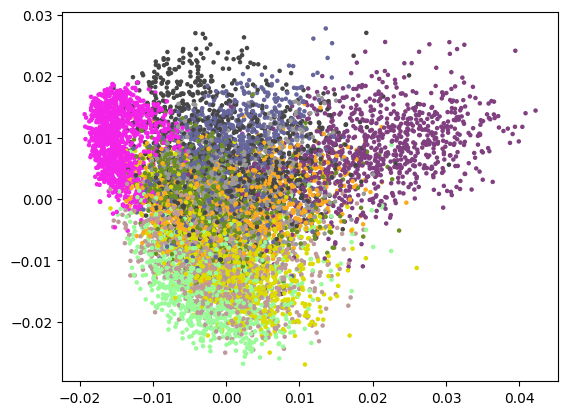

Fitting PCA from feature representation


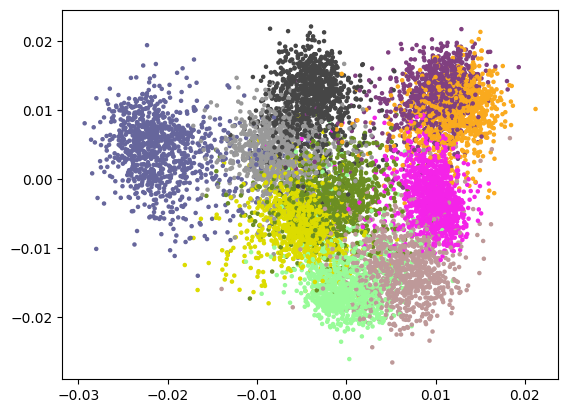

In [8]:
def get_colormap():
    # Cityscapes colormap for first 10 classes
    colormap = np.zeros((10, 3), dtype=np.uint8)
    colormap[0] = [128, 64, 128]
    colormap[1] = [244, 35, 232]
    colormap[2] = [70, 70, 70]
    colormap[3] = [102, 102, 156]
    colormap[4] = [190, 153, 153]
    colormap[5] = [153, 153, 153]
    colormap[6] = [250, 170, 30]
    colormap[7] = [220, 220, 0]
    colormap[8] = [107, 142, 35]
    colormap[9] = [152, 251, 152]
    return colormap


if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"= Using device {device}")
    emb_size = 32
    model = SimpleMetricEmbedding(1, emb_size).to(device)
    model.load_state_dict(torch.load("drive/MyDrive/Colab Notebooks/model.pth"))

    colormap = get_colormap()
    mnist_download_root = "./mnist/"
    ds_test = MNISTMetricDataset(mnist_download_root, split='test')
    X = ds_test.images
    Y = ds_test.targets
    print("Fitting PCA directly from images...")
    test_img_rep2d = torch.pca_lowrank(ds_test.images.view(-1, 28 * 28), 2)[0]
    plt.scatter(test_img_rep2d[:, 0], test_img_rep2d[:, 1], color=colormap[Y[:]] / 255., s=5)
    plt.show()
    plt.figure()

    print("Fitting PCA from feature representation")
    with torch.no_grad():
        model.eval()
        test_rep = model.get_features(X.unsqueeze(1).to(device))
        test_rep2d = torch.pca_lowrank(test_rep, 2)[0].cpu().numpy()
        plt.scatter(test_rep2d[:, 0], test_rep2d[:, 1], color=colormap[Y[:]] / 255., s=5)
        plt.show()